In [45]:
# --- SETUP: IMPORTS AND CONFIGURATION ---
from pathlib import Path
from typing import Callable, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from PyLTSpice.log.ltsteps import LTSpiceLogReader

# --- Setup ---
pd.set_option('display.float_format', '{:.5f}'.format)

# --- Paths ---
PROJECT_ROOT       = Path("..").resolve()
PROJECT_SIM_FOLDER = PROJECT_ROOT / "res" / "srcs" / "project-02"
OUTPUT_SIM_FOLDER  = PROJECT_ROOT / "notebooks" / "output" / "project-02" / "sim"
OUTPUT_FIG_FOLDER  = PROJECT_ROOT / "notebooks" / "output" / "project-02" / "fig"
OUTPUT_SIM_FOLDER.mkdir(parents=True, exist_ok=True)
OUTPUT_FIG_FOLDER.mkdir(parents=True, exist_ok=True)

# --- LTspice runner (update path to match your installation) ---
LTSPICE_EXE = r"D:\Softwares\ADI\LTspiceXVII\XVIIx64.exe"
runner = SimRunner(
    output_folder=OUTPUT_SIM_FOLDER, # pyright: ignore[reportArgumentType]
    simulator=LTSPICE_EXE,
    parallel_sims=4,
)

# --- Project constants ---
VDD_NOM   = 1.0   # nominal supply voltage [V]
W_MIN     = 120e-9  # technology minimum channel width [m] (consistent with project-01 NMOS sizing)
RSNM_TARGET = 0.120  # target READ SNM robustness threshold [V]  (STEP 1)
VDD_SWEEP = np.round(np.arange(1.0, 0.35, -0.1), 2)  # VDD sweep 1.0V -> 0.4V @ 0.1V  (STEP 3, STEP 4)
N_MC_RUNS = 2500  # Monte Carlo runs per VDD step  (STEP 3, STEP 4)

# --- Helper functions ---
def _transform_dataframe(
    df: pd.DataFrame,
    rename_dict: dict[str, str] = None, # pyright: ignore[reportArgumentType]
    scale_dict: dict[str, Union[str, Callable[[pd.Series], pd.Series]]] = None # pyright: ignore[reportArgumentType]
) -> pd.DataFrame:
    """Transforms a DataFrame by applying scaling strategies and renaming columns.

    Args:
        df (pd.DataFrame): The input DataFrame to transform.
        rename_dict (dict[str, str], optional): Mapping of original column names to new names. Defaults to None.
        scale_dict (dict[str, Union[str, Callable]], optional): Mapping of original column names to scaling configurations.
            Supported string strategies are 'minmax' and 'standard'. Custom callables mapping a Series to a Series are also supported. Defaults to None.

    Returns:
        pd.DataFrame: A new DataFrame instance with applied transformations.

    Raises:
        ValueError: If an unsupported string scaling strategy is provided.
    """
    # Create a copy to prevent mutating the original reference
    processed_df = df.copy()

    # Apply scaling transformations using the original column names
    if scale_dict:
        for col, method in scale_dict.items():
            if col not in processed_df.columns:
                continue

            series = processed_df[col]

            if callable(method):
                processed_df[col] = method(series)
            elif isinstance(method, str):
                method_lower = method.lower()

                if method_lower == 'minmax':
                    col_min = series.min()
                    col_max = series.max()
                    if col_max != col_min:
                        processed_df[col] = (series - col_min) / (col_max - col_min)
                    else:
                        processed_df[col] = 0.0

                elif method_lower == 'standard':
                    col_mean = series.mean()
                    col_std = series.std()
                    if col_std != 0:
                        processed_df[col] = (series - col_mean) / col_std
                    else:
                        processed_df[col] = 0.0
                else:
                    raise ValueError(f"Unsupported scaling strategy: '{method}'. Use 'minmax', 'standard', or a custom callable.")

    # Apply header renaming after scaling operations
    if rename_dict:
        processed_df = processed_df.rename(columns=rename_dict)

    return processed_df

def _format_cell(val, decimals: int = 5) -> str:
    """Formats a DataFrame cell to prevent raw object representation and strip floating-point artifacts.

    Args:
        val (Any): The cell value to format.
        decimals (int, optional): Number of decimal places to round floats. Defaults to 5.

    Returns:
        str: The formatted string representation of the cell.
    """
    if pd.isna(val):
        return "NaN"

    if isinstance(val, (float, np.floating)):
        # Round the value to eliminate artifacts from operations like * 1e15
        rounded_val = round(float(val), decimals)

        # Cast to integer string if the rounded value has no fractional part
        if rounded_val.is_integer():
            return str(int(rounded_val))

        return str(rounded_val)

    return str(val)

def _summary_display(df: pd.DataFrame, n_head: int = 5, n_tail: int = 0) -> pd.DataFrame:
    """Generates a string-formatted summary DataFrame with a central ellipsis row for UI rendering.

    Args:
        df (pd.DataFrame): The target DataFrame.
        n_head (int, optional): Number of top rows to display. Defaults to 5.
        n_tail (int, optional): Number of bottom rows to display. Set to >0 to append the tail. Set to -1 to omit the tail. Defaults to 0.

    Returns:
        pd.DataFrame: A string-cast DataFrame containing the sliced data and the ellipsis separator.
    """
    # Format and isolate the head components
    df_head = df.head(n_head).apply(lambda col: col.map(_format_cell))

    # Generate the single ellipsis row container
    if n_tail != -1:
        dummy_row = pd.DataFrame(
            [['...'] * len(df.columns)],
            columns=df.columns,
            index=['...']
        )

        chunks = [df_head, dummy_row]
    else:
        chunks = [df_head]

    # Trigger Behavior 2 if n_tail is explicitly requested
    if n_tail > 0:
        df_tail = df.tail(n_tail).apply(lambda col: col.map(_format_cell))
        chunks.append(df_tail)

    return pd.concat(chunks)

def _get_measure(reader: LTSpiceLogReader, name: str) -> float:
    """Extracts a scalar measurement from an LTSpice log reader, handling version-dependent return types.

    PyLTSpice may return either a bare scalar or a single-element sequence for non-stepped
    simulations. This helper normalizes both cases to ensure version-agnostic evaluation.

    Args:
        reader (LTSpiceLogReader): The log reader instance parsing the simulation output.
        name (str): The measurement identifier to retrieve.

    Returns:
        float: The extracted measurement cast to a scalar float.
    """
    val = reader[name]
    return float(val[0]) if hasattr(val, "__len__") else float(val)

def _extract_step_array(reader: LTSpiceLogReader, name: str) -> np.ndarray:
    """Extracts a full measurement array across all steps of a stepped LTspice simulation.

    Args:
        reader (LTSpiceLogReader): The log reader instance parsing the simulation output.
        name (str): The measurement identifier to retrieve.

    Returns:
        np.ndarray: The measurement values for every step, cast to float64.
    """
    return np.array(reader[name], dtype=np.float64)

## Step 01 – Cell Sizing (Cell Ratio & Pull-up Ratio)

Size the **access**, **pull-down**, and **pull-up** transistors of the 6T SRAM
cell by sweeping the pull-down width $W_{pdn} = pd \cdot W_{min}$ while
keeping $W_{ax} = W_{pu} = W_{min}$, and extracting the **butterfly curve**
(VTC of the two cross-coupled inverters) at each step for both **HOLD** and
**READ**.

The **graphical SNM** — the side of the largest square inscribed in the
butterfly curve — is computed numerically at each `pd` step. $W_{pdn}$ is
increased until the READ SNM (the more critical of the two) reaches the
target robustness threshold (`150mV`).

`Cell Ratio` and `Pull-up Ratio` are derived from the final sizing and
propagate to every subsequent step as the fixed cell geometry.


In [46]:
# --- STEP 01.1: RUN SIMULATIONS (HOLD & READ) ---
# sram_sizing_sweep_hold.asc: breaks the cross-coupled loop (one inverter's gate
#   tied to a fixed bias, WL = 0 -> access transistors off) and sweeps
#   `.dc Vsweep 0 {VDD} {step}` directly on the disconnected storage node,
#   with `.step param pd 1 4.5 0.5` (Wpdn = pd * wmin) and Wax = Wpu = wmin
#   fixed. V(q) is read as the response to the imposed Vsweep, tracing the
#   HOLD-configuration VTC branch used for the graphical SNM in STEP 01.2.
#
# sram_sizing_sweep_read.asc: the same broken-loop sweep is repeated with the READ topology (bitlines
#   precharged to VDD, wordline enabled, access transistors engaged) via a
#   dedicated .asc variant, since READ requires the bitline/wordline biasing
#   absent from the HOLD schematic (WL = 0 there).

# HOLD Simulation
print("Running SRAM pull-down sizing sweep (HOLD)...")
netlist_hold = SpiceEditor(PROJECT_SIM_FOLDER / "01-sizing" / "sram_sizing_sweep_hold.asc")
netlist_hold.set_parameters(wmin=W_MIN, wax=W_MIN, wpu=W_MIN)
_, log_hold = runner.run_now(netlist_hold)
print(f"Done.  Log: {log_hold}")

# READ Simulation
print("Running SRAM pull-down sizing sweep (READ)...")
netlist_read = SpiceEditor(PROJECT_SIM_FOLDER / "01-sizing" / "sram_sizing_sweep_read.asc")
netlist_read.set_parameters(wmin=W_MIN, wax=W_MIN, wpu=W_MIN)
_, log_read = runner.run_now(netlist_read)
print(f"Done.  Log: {log_read}")

Running SRAM pull-down sizing sweep (HOLD)...
Done.  Log: C:\Users\stefa\Workspace\01-UNICAL\Low_power-projects\notebooks\output\project-02\sim\sram_sizing_sweep_hold_1.log
Running SRAM pull-down sizing sweep (READ)...
Done.  Log: C:\Users\stefa\Workspace\01-UNICAL\Low_power-projects\notebooks\output\project-02\sim\sram_sizing_sweep_read_2.log


In [47]:
from scipy.interpolate import interp1d
from scipy.optimize import minimize

def find_max_inscribed_square_discrete(x_lower, y_lower, x_upper, y_upper, interpolation_kind='linear'):
    """
    Finds the maximum inscribed square between two boundaries defined by discrete points.
    Robust version with extrapolation enabled for numerical solver compatibility.
    """
    # 1. Create continuous functions.
    # Added bounds_error=False and fill_value="extrapolate" to prevent finite-difference crashes
    f_lower = interp1d(
        x_lower, y_lower,
        kind=interpolation_kind,
        assume_sorted=False,
        bounds_error=False,
        fill_value="extrapolate" # pyright: ignore[reportArgumentType]
    )
    f_upper = interp1d(
        x_upper, y_upper,
        kind=interpolation_kind,
        assume_sorted=False,
        bounds_error=False,
        fill_value="extrapolate" # pyright: ignore[reportArgumentType]
    )

    # 2. Determine the valid overlapping domain
    min_x = max(np.min(x_lower), np.min(x_upper))
    max_x = min(np.max(x_lower), np.max(x_upper))
    x_bounds = (min_x, max_x)

    # 3. Objective function
    def objective(p):
        return -p[2]  # Maximize s

    # 4. Constraints
    def constraints(p):
        x, y, s = p
        return [
            y - f_lower(x),
            f_upper(x) - y,
            y - f_lower(x + s),
            f_upper(x + s) - y,
            (y + s) - f_lower(x),
            f_upper(x) - (y + s),
            (y + s) - f_lower(x + s),
            f_upper(x + s) - (y + s),
            x - x_bounds[0],
            x_bounds[1] - (x + s)
        ]

    # 5. Smart initial guess
    mid_x = (x_bounds[0] + x_bounds[1]) / 2.0
    initial_s = (x_bounds[1] - x_bounds[0]) / 10.0
    initial_y = f_lower(mid_x) + (f_upper(mid_x) - f_lower(mid_x)) / 2.0 - initial_s / 2.0

    initial_guess = [mid_x - initial_s / 2.0, initial_y, initial_s]

    # 6. Explicit boundaries for variables [x, y, s]
    # This prevents the solver from exploring non-physical domains
    bnds = (
        (min_x, max_x),                             # x bounds
        (None, None),                               # y bounds (managed by constraints)
        (0.0, x_bounds[1] - x_bounds[0])            # s bounds (must be positive and <= domain width)
    )

    # 7. Run optimization
    con = {'type': 'ineq', 'fun': constraints}

    result = minimize(
        objective,
        initial_guess,
        method='SLSQP',
        bounds=bnds,
        constraints=con,
        options={'ftol': 1e-9} # Tighter tolerance for high-precision vector data
    )

    if result.success:
        x, y, s = result.x
        return {
            "bottom_left": (x, y),
            "bottom_right": (x + s, y),
            "top_left": (x, y + s),
            "top_right": (x + s, y + s),
            "side_length": s,
            "success": True
        }
    else:
        return {
            "bottom_left": (None, None),
            "bottom_right": (None, None),
            "top_left": (None, None),
            "top_right": (None, None),
            "side_length": None,
            "success": False
        }

In [48]:
# --- STEP 01.2: EXTRACT VTC AND COMPUTE GRAPHICAL HSNM & RSNM ---
# This traces ONE VTC branch; by the cell's symmetry, the second butterfly
# branch is obtained by mirroring (swapping axes) rather than simulated
# separately — matching the reference report's "Curva 2 (specchiata)" approach.
#
# The same broken-loop sweep is repeated with the READ topology (bitlines
# precharged to VDD, wordline enabled, access transistors engaged) via a
# dedicated .asc variant, since READ requires the bitline/wordline biasing
# absent from the HOLD schematic (WL = 0 there).

PD_START, PD_STOP, PD_STEP = 1.0, 16.0, 2.0
pd_values = np.arange(PD_START, PD_STOP + PD_STEP / 2, PD_STEP)

# HOLD
raw_hold = RawRead(log_hold.as_posix().replace(".log", ".raw")) # pyright: ignore[reportOptionalMemberAccess]
hold_results = []
for step_idx, pd_val in enumerate(pd_values):
    v_q    = raw_hold.get_trace("V(q)").get_wave(step_idx)
    v_qneg = raw_hold.get_trace("V(qneg)").get_wave(step_idx)

    sqr_coords = find_max_inscribed_square_discrete(v_qneg, v_q, v_q, v_qneg, interpolation_kind='cubic')

    hold_results.append({
        "pd":           pd_val,
        "wpdn":         pd_val * W_MIN,
        "hsnm":         sqr_coords["side_length"],
        "vq":           v_q,
        "vqneg":        v_qneg,
        "sqr_coords":   sqr_coords
    })
df_hold = pd.DataFrame(hold_results, columns=["pd", "wpdn", "hsnm"])

# READ
raw_read = RawRead(log_read.as_posix().replace(".log", ".raw")) # pyright: ignore[reportOptionalMemberAccess]
read_results = []
for step_idx, pd_val in enumerate(pd_values):
    v_q    = raw_read.get_trace("V(q)").get_wave(step_idx)
    v_qneg = raw_read.get_trace("V(qneg)").get_wave(step_idx)

    sqr_coords = find_max_inscribed_square_discrete(v_qneg, v_q, v_q, v_qneg, interpolation_kind='cubic')

    read_results.append({
        "pd":         pd_val,
        "wpdn":       pd_val * W_MIN,
        "rsnm":       sqr_coords["side_length"],
        "vq":           v_q,
        "vqneg":        v_qneg,
        "sqr_coords":   sqr_coords
    })
df_read = pd.DataFrame(read_results, columns=["pd", "wpdn", "rsnm"])

df_sizing = pd.merge(df_hold, df_read, on=["pd", "wpdn"])

print(f"Extracted {len(df_sizing)} steps (pd: {PD_START}-{PD_STOP} @ {PD_STEP})")
_summary_display(
    _transform_dataframe(
        df_sizing,
        {"pd": "pd [1]", "wpdn": "Wpdn [nm]", "hsnm": "HSNM [mV]", "rsnm": "RSNM [mV]"},
        {"wpdn": lambda x: x * 1e9, "hsnm": lambda x: x * 1e3, "rsnm": lambda x: x * 1e3}
    ),
    n_head=len(df_sizing),
    n_tail=-1
)

Extracted 8 steps (pd: 1.0-16.0 @ 2.0)


,pd [1],Wpdn [nm],HSNM [mV],RSNM [mV]
0,1,120,241.04567,NaN
1,3,360,216.35045,84.01627
2,5,600,199.85351,109.55761
3,7,840,187.41689,120.00395
4,9,1080,177.36133,124.53239
5,11,1320,168.91429,126.25493
6,13,1560,161.64472,126.51314
7,15,1800,155.28104,125.96397


<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
C:\Users\stefa\AppData\Local\Temp\ipykernel_36116\2660044439.py:31: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel("$\overline{Q}$ (V)", fontsize=12)
C:\Users\stefa\AppData\Local\Temp\ipykernel_36116\2660044439.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


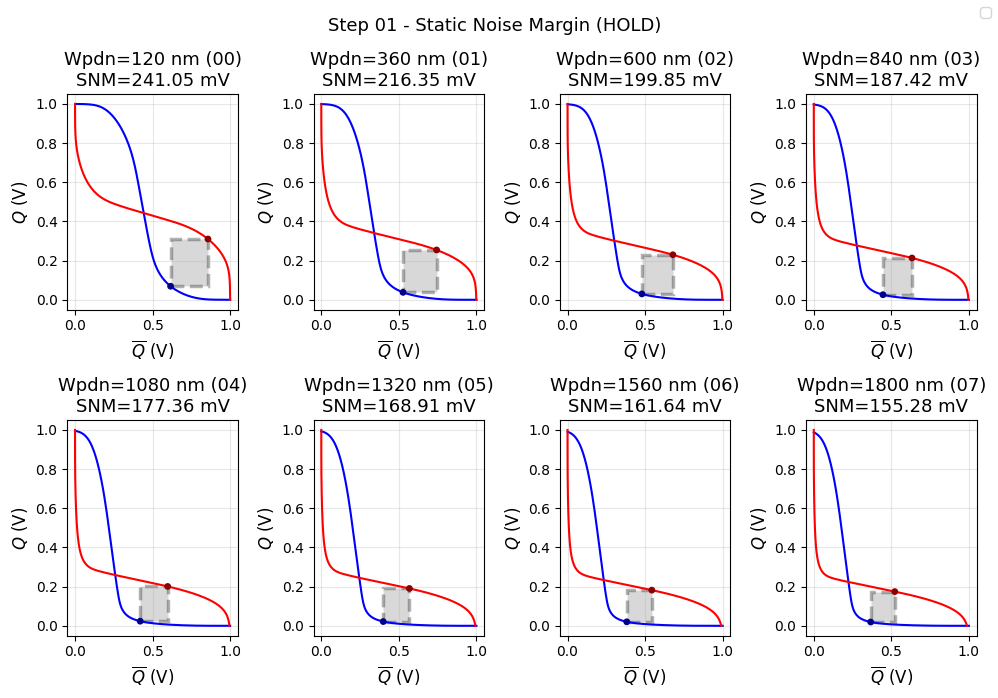

C:\Users\stefa\AppData\Local\Temp\ipykernel_36116\2660044439.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


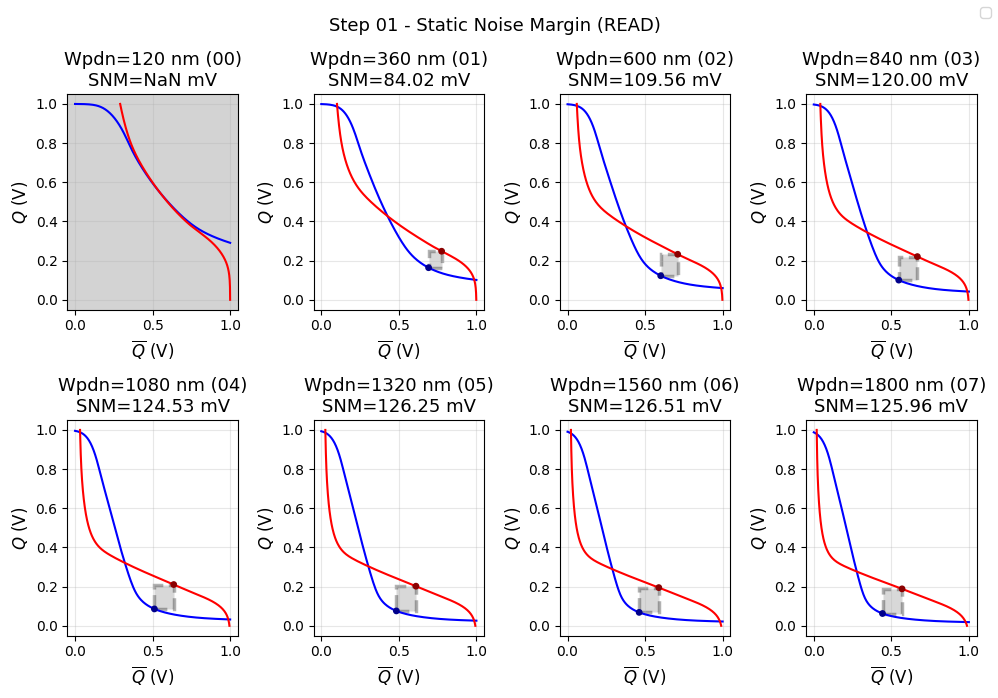

In [55]:
# --- STEP 01.3: PLOT BUTTERFLY CURVES ---

def plot_butterfly(ax, res, idx: int):
    ax.plot(res[idx]["vqneg"], res[idx]["vq"], label="VTC 1", color="blue")
    ax.plot(res[idx]["vq"], res[idx]["vqneg"], label="VTC 2 (Mirrored)", color="red")

    x, y = res[idx]["sqr_coords"]["bottom_left"]
    s = res[idx]["sqr_coords"]["side_length"]

    if s:
        # Create a Rectangle patch (anchor point is bottom-left)
        rect = patches.Rectangle(
            (x, y), s, s,
            linewidth=2.5,
            edgecolor='black',
            linestyle='--',
            facecolor='gray',
            alpha=0.3, # Adds transparency to the fill color
            label=f'Max Square (SNM = {s:.4f} V)'
        )

        ax.add_patch(rect)
        corners_x = [x, x+s]
        corners_y = [y, y+s]
        ax.scatter(corners_x, corners_y, color=['darkblue', 'darkred'], marker='o', zorder=5, s=15)
        ax.set_title(f"Wpdn={res[idx]['wpdn'] * 1e9:.0f} nm ({idx:02})\nSNM={s * 1e3:.2f} mV", fontsize=13)
    else:
        ax.set_facecolor('lightgray')
        ax.set_title(f"Wpdn={res[idx]['wpdn'] * 1e9:.0f} nm ({idx:02})\nSNM=NaN mV", fontsize=13)

    ax.set_xlabel("$\overline{Q}$ (V)", fontsize=12)
    ax.set_ylabel("$Q$ (V)", fontsize=12)
    #ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig, axs = plt.subplots(2, 4, figsize=(10, 7))
fig.suptitle("Step 01 - Static Noise Margin (HOLD)", fontsize=13)
fig.legend()

plot_butterfly(axs[0, 0], hold_results, 0)
plot_butterfly(axs[0, 1], hold_results, 1)
plot_butterfly(axs[0, 2], hold_results, 2)
plot_butterfly(axs[0, 3], hold_results, 3)
plot_butterfly(axs[1, 0], hold_results, 4)
plot_butterfly(axs[1, 1], hold_results, 5)
plot_butterfly(axs[1, 2], hold_results, 6)
plot_butterfly(axs[1, 3], hold_results, 7)

plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step01_butterfly-hold.png", dpi=300)
plt.show()

fig, axs = plt.subplots(2, 4, figsize=(10, 7))
fig.suptitle("Step 01 - Static Noise Margin (READ)", fontsize=13)
fig.legend()

plot_butterfly(axs[0, 0], read_results, 0)
plot_butterfly(axs[0, 1], read_results, 1)
plot_butterfly(axs[0, 2], read_results, 2)
plot_butterfly(axs[0, 3], read_results, 3)
plot_butterfly(axs[1, 0], read_results, 4)
plot_butterfly(axs[1, 1], read_results, 5)
plot_butterfly(axs[1, 2], read_results, 6)
plot_butterfly(axs[1, 3], read_results, 7)

plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step01_butterfly-read.png", dpi=300)
plt.show()

In [50]:
# --- STEP 01.4: SELECT MINIMUM Wpdn MEETING THE RSNM TARGET ---
# Select the first (smallest) pd step whose RSNM reaches RSNM_TARGET,
# avoiding unnecessary area overhead from oversizing (matches the reference
# methodology's iterative approach).

meets_target = df_sizing[df_sizing["rsnm"] >= RSNM_TARGET]
assert not meets_target.empty, (
    f"No pd step reaches the RSNM target of {RSNM_TARGET * 1e3:.0f} mV; "
    "extend the pd sweep range."
)

sizing_row = meets_target.iloc[0]
wax_final  = W_MIN
wpu_final  = W_MIN
wpdn_final = float(sizing_row["wpdn"])

cell_ratio    = wpdn_final / wax_final  # CR = Wpdn / Wax  (Eq. 1.1, Lpdn = Lax)
pullup_ratio  = wpu_final / wax_final   # PR = Wpu / Wax   (Eq. 1.2, Lpu = Lax)

print("=" * 60)
print("STEP 01 SIZING SUMMARY")
print("=" * 60)
print(f"  Wax   :  {wax_final  * 1e9:.1f} nm  (= Wmin)")
print(f"  Wpu   :  {wpu_final  * 1e9:.1f} nm  (= Wmin)")
print(f"  Wpdn  :  {wpdn_final * 1e9:.1f} nm  (pd = {sizing_row['pd']:.2f})")
print()
print(f"  HSNM  :  {sizing_row['hsnm'] * 1e3:.2f} mV")
print(f"  RSNM  :  {sizing_row['rsnm'] * 1e3:.2f} mV  (target: {RSNM_TARGET * 1e3:.0f} mV)")
print()
print(f"  Cell Ratio (CR)    :  {cell_ratio:.3f}")
print(f"  Pull-up Ratio (PR) :  {pullup_ratio:.3f}")
print("=" * 60)

STEP 01 SIZING SUMMARY
  Wax   :  120.0 nm  (= Wmin)
  Wpu   :  120.0 nm  (= Wmin)
  Wpdn  :  840.0 nm  (pd = 7.00)

  HSNM  :  187.42 mV
  RSNM  :  120.00 mV  (target: 120 mV)

  Cell Ratio (CR)    :  7.000
  Pull-up Ratio (PR) :  1.000


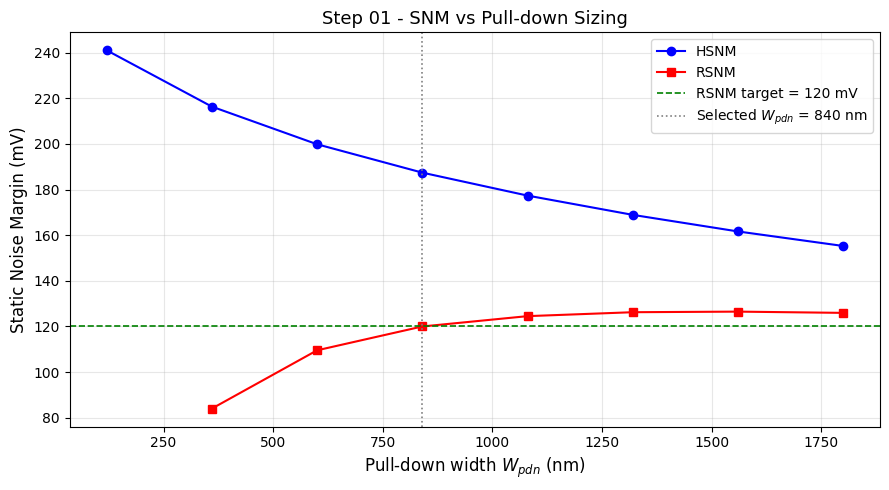

In [51]:
# --- STEP 01.5: PLOT HSNM/RSNM VS Wpdn ---

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sizing["wpdn"] * 1e9, df_sizing["hsnm"] * 1e3, "o-",
        color="blue", label="HSNM")
ax.plot(df_sizing["wpdn"] * 1e9, df_sizing["rsnm"] * 1e3, "s-",
        color="red", label="RSNM")
ax.axhline(RSNM_TARGET * 1e3, color="green", linestyle="--", linewidth=1.2,
           label=f"RSNM target = {RSNM_TARGET * 1e3:.0f} mV")
ax.axvline(wpdn_final * 1e9, color="gray", linestyle=":", linewidth=1.2,
           label=f"Selected $W_{{pdn}}$ = {wpdn_final * 1e9:.0f} nm")

ax.set_xlabel("Pull-down width $W_{pdn}$ (nm)", fontsize=12)
ax.set_ylabel("Static Noise Margin (mV)", fontsize=12)
ax.set_title("Step 01 - SNM vs Pull-down Sizing", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step01_snm_vs_sizing.png", dpi=300)
plt.show()

## Step 02 – Seevinck Method Validation

Cross-check the graphical SNM from `Step 01` against the **Seevinck method**,
which computes SNM directly from an LTspice `.dc` sweep via the coordinate
rotation $x = \frac{1}{\sqrt{2}}u + \frac{1}{\sqrt{2}}v$,
$y = -\frac{1}{\sqrt{2}}u + \frac{1}{\sqrt{2}}v$.

The rotated schematic yields the SNM as a **single scalar `.meas`** per run,
which is required for the Monte Carlo statistical post-processing in `Step
03` and `Step 04` (a per-run butterfly-curve extraction would not scale to
`2500` runs per VDD point).


In [ ]:
# --- STEP 02.1: RUN SEEVINCK-METHOD HOLD AND READ SIMULATIONS ---
# sram_seevinck.asc implements the rotated (u, v) schematic (Fig. 2.4 of the
# reference) with a `hold_read` flag selecting the HOLD or READ topology,
# and a `.meas` extracting the diagonal maximum directly from the .dc sweep.

print("Running Seevinck-method HOLD simulation...")
netlist_seevinck_hold = SpiceEditor(
    PROJECT_SIM_FOLDER / "02-seevinck" / "sram_seevinck.asc"
)
netlist_seevinck_hold.set_parameters(wax=wax_final, wpu=wpu_final, wpdn=wpdn_final)
netlist_seevinck_hold.set_parameter("hold_read", 0)  # 0 = HOLD topology
_, log_seevinck_hold = runner.run_now(netlist_seevinck_hold)
print(f"Done.  Log: {log_seevinck_hold}")

print("Running Seevinck-method READ simulation...")
netlist_seevinck_read = SpiceEditor(
    PROJECT_SIM_FOLDER / "02-seevinck" / "sram_seevinck.asc"
)
netlist_seevinck_read.set_parameters(wax=wax_final, wpu=wpu_final, wpdn=wpdn_final)
netlist_seevinck_read.set_parameter("hold_read", 1)  # 1 = READ topology
_, log_seevinck_read = runner.run_now(netlist_seevinck_read)
print(f"Done.  Log: {log_seevinck_read}")

In [ ]:
# --- STEP 02.2: EXTRACT AND CROSS-CHECK SNM VALUES ---
# SNM = max diagonal distance (v_max) * cos(45deg), per the reference's
# 4-step Seevinck procedure (subtract VTCs, find per-lobe maxima, take the
# minimum of the two, scale by cos(45deg)).

data_seevinck_hold = LTSpiceLogReader(log_seevinck_hold.as_posix()) # pyright: ignore[reportOptionalMemberAccess]
data_seevinck_read = LTSpiceLogReader(log_seevinck_read.as_posix()) # pyright: ignore[reportOptionalMemberAccess]

hsnm_seevinck = _get_measure(data_seevinck_hold, "snm") * np.cos(np.deg2rad(45))
rsnm_seevinck = _get_measure(data_seevinck_read, "snm") * np.cos(np.deg2rad(45))

hsnm_graphical = float(sizing_row["hsnm"])
rsnm_graphical = float(sizing_row["rsnm"])

print("=" * 60)
print("SEEVINCK METHOD CROSS-CHECK  (Step 02 vs Step 01)")
print("=" * 60)
print(f"  HSNM  (graphical):  {hsnm_graphical * 1e3:.2f} mV")
print(f"  HSNM  (Seevinck) :  {hsnm_seevinck  * 1e3:.2f} mV")
print(f"    |Error|: {np.abs(hsnm_graphical - hsnm_seevinck) * 1e3:.3f} mV "
      f"({(np.abs(hsnm_graphical - hsnm_seevinck) / hsnm_graphical) * 100:.2f}%)")
print()
print(f"  RSNM  (graphical):  {rsnm_graphical * 1e3:.2f} mV")
print(f"  RSNM  (Seevinck) :  {rsnm_seevinck  * 1e3:.2f} mV")
print(f"    |Error|: {np.abs(rsnm_graphical - rsnm_seevinck) * 1e3:.3f} mV "
      f"({(np.abs(rsnm_graphical - rsnm_seevinck) / rsnm_graphical) * 100:.2f}%)")
print("=" * 60)

In [ ]:
# --- STEP 02.3: PLOT GRAPHICAL VS SEEVINCK SNM COMPARISON ---

fig, ax = plt.subplots(figsize=(7, 5))
labels = ["HSNM", "RSNM"]
graphical_vals = [hsnm_graphical * 1e3, rsnm_graphical * 1e3]
seevinck_vals  = [hsnm_seevinck  * 1e3, rsnm_seevinck  * 1e3]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width / 2, graphical_vals, width, label="Graphical (Step 01)", color="steelblue")
ax.bar(x + width / 2, seevinck_vals,  width, label="Seevinck (Step 02)",  color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("SNM (mV)", fontsize=12)
ax.set_title("Step 02 - Graphical vs Seevinck SNM Extraction", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step02_seevinck_crosscheck.png", dpi=300)
plt.show()

## Step 03 – Inter-die Process Variation (Monte Carlo)

Characterize **inter-die** variation — a global $V_{TH}$ shift shared by
every transistor on the die — by running `2500`-run Monte Carlo sweeps on
the Seevinck-method schematic (`Step 02`) at each `VDD_SWEEP` point, with a
**single shared Gaussian random variable** driving every MOSFET's threshold
voltage.

At each VDD step, **leakage power**, **HSNM**, and **RSNM** are extracted per
run and reduced to mean/variance, together with their **DRV** distribution
(the per-run minimum VDD at which the cell still retains data).


In [ ]:
# --- STEP 03.1: RUN INTER-DIE MONTE CARLO SWEEP (ALL VDD STEPS) ---
# sram_mc_interdie.asc's single-inverter Seevinck topology cannot produce
# HSNM and RSNM in the same run (WL is fixed per invocation via `hold_read`),
# so each VDD point requires two runs: hold_read=0 (HOLD, also carries the
# `leakage` measurement) and hold_read=1 (READ). `.options seed` in the
# netlist keeps the `dvth` draw sequence identical across both invocations,
# so run `i` in the HOLD log and run `i` in the READ log share the same
# mismatch sample — required for the per-run DRV correlation in STEP 03.3.

interdie_logs_hold = {}
interdie_logs_read = {}
for vdd in VDD_SWEEP:
    print(f"Running inter-die MC sweep at VDD = {vdd:.1f} V...")

    netlist_hold = SpiceEditor(
        PROJECT_SIM_FOLDER / "03-montecarlo_interdie" / "sram_mc_interdie.asc"
    )
    netlist_hold.set_parameters(
        wax=wax_final, wpu=wpu_final, wpdn=wpdn_final, vdd=vdd, hold_read=0
    )
    _, log_hold = runner.run_now(netlist_hold)
    interdie_logs_hold[vdd] = log_hold

    netlist_read = SpiceEditor(
        PROJECT_SIM_FOLDER / "03-montecarlo_interdie" / "sram_mc_interdie.asc"
    )
    netlist_read.set_parameters(
        wax=wax_final, wpu=wpu_final, wpdn=wpdn_final, vdd=vdd, hold_read=1
    )
    _, log_read = runner.run_now(netlist_read)
    interdie_logs_read[vdd] = log_read

    print(f"  Done.  HOLD log: {log_hold}")
    print(f"  Done.  READ log: {log_read}")


In [ ]:
# --- STEP 03.2: EXTRACT PER-RUN MEASUREMENTS AND REDUCE TO MEAN/VARIANCE ---
# HSNM is read from the HOLD log's `snm_raw`, RSNM from the paired READ
# log's `snm_raw` (same run index, same dvth draw), leakage from the HOLD
# log only (READ state carries active access-transistor current, not a
# pure leakage figure). Both SNM measurements are the raw Seevinck diagonal
# and are scaled by cos(45deg) here to keep the .meas expressions simple.

interdie_rows = []
interdie_raw_snm = {}   # per-VDD raw (unreduced) SNM/leakage arrays, for distribution plots

for vdd in VDD_SWEEP:
    data_hold = LTSpiceLogReader(interdie_logs_hold[vdd].as_posix()) # pyright: ignore[reportOptionalMemberAccess]
    data_read = LTSpiceLogReader(interdie_logs_read[vdd].as_posix()) # pyright: ignore[reportOptionalMemberAccess]

    leakage_arr = _extract_step_array(data_hold, "leakage")
    hsnm_arr    = _extract_step_array(data_hold, "snm_raw") * np.cos(np.deg2rad(45))
    rsnm_arr    = _extract_step_array(data_read, "snm_raw") * np.cos(np.deg2rad(45))

    interdie_raw_snm[vdd] = {"leakage": leakage_arr, "hsnm": hsnm_arr, "rsnm": rsnm_arr}

    interdie_rows.append({
        "vdd":            vdd,
        "leakage_mean":   np.nanmean(leakage_arr),
        "leakage_var":    np.nanvar(leakage_arr),
        "hsnm_mean":      np.nanmean(hsnm_arr),
        "hsnm_var":       np.nanvar(hsnm_arr),
        "rsnm_mean":      np.nanmean(rsnm_arr),
        "rsnm_var":       np.nanvar(rsnm_arr),
        "valid_runs":     int(np.sum(~np.isnan(rsnm_arr))),
    })

df_interdie = pd.DataFrame(interdie_rows)

print(f"Inter-die MC summary: {len(VDD_SWEEP)} VDD steps x up to {N_MC_RUNS} runs")
_summary_display(
    _transform_dataframe(
        df_interdie,
        {
            "vdd": "VDD [V]", "leakage_mean": "Leakage (mean) [nW]", "leakage_var": "Leakage (var) [fW]",
            "hsnm_mean": "HSNM (mean) [mV]", "hsnm_var": "HSNM (var) [mV^2]",
            "rsnm_mean": "RSNM (mean) [mV]", "rsnm_var": "RSNM (var) [mV^2]",
            "valid_runs": "Valid runs",
        },
        {
            "leakage_mean": lambda x: x * 1e9, "leakage_var": lambda x: x * 1e15,
            "hsnm_mean": lambda x: x * 1e3, "hsnm_var": lambda x: x * 1e6,
            "rsnm_mean": lambda x: x * 1e3, "rsnm_var": lambda x: x * 1e6,
        }
    ),
    n_head=4,
    n_tail=3
)


In [ ]:
# --- STEP 03.3: EXTRACT PER-RUN DRV (INTER-DIE) ---
# DRV is the lowest VDD_SWEEP point at which a given MC run's HSNM and RSNM
# are BOTH still positive (data still retained); once either margin drops to
# zero or below at a lower VDD, the last surviving VDD above it is recorded.
# Runs that retain data across the full sweep are right-censored at the
# lowest tested VDD (extend VDD_SWEEP downward to resolve these fully).

n_runs_max = max(len(v["rsnm"]) for v in interdie_raw_snm.values())
drv_interdie = np.full(n_runs_max, np.nan)

for run_idx in range(n_runs_max):
    last_good_vdd = np.nan
    for vdd in sorted(VDD_SWEEP, reverse=True):  # descending: track the last surviving VDD
        rsnm_run = interdie_raw_snm[vdd]["rsnm"][run_idx] if run_idx < len(interdie_raw_snm[vdd]["rsnm"]) else np.nan
        hsnm_run = interdie_raw_snm[vdd]["hsnm"][run_idx] if run_idx < len(interdie_raw_snm[vdd]["hsnm"]) else np.nan
        if np.isnan(rsnm_run) or np.isnan(hsnm_run) or rsnm_run <= 0 or hsnm_run <= 0:
            break
        last_good_vdd = vdd
    drv_interdie[run_idx] = last_good_vdd

drv_interdie_valid = drv_interdie[~np.isnan(drv_interdie)]
print(f"Inter-die DRV extracted for {len(drv_interdie_valid)}/{n_runs_max} runs "
      f"(remaining runs failed already at the highest tested VDD)")


In [ ]:
# --- STEP 03.4: PLOT MEAN +/- STD OF HSNM, RSNM, AND LEAKAGE VS VDD ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

hsnm_std = np.sqrt(df_interdie["hsnm_var"])
rsnm_std = np.sqrt(df_interdie["rsnm_var"])

ax1.errorbar(df_interdie["vdd"], df_interdie["hsnm_mean"] * 1e3, yerr=hsnm_std * 1e3,
             fmt="o-", color="blue", label="HSNM", capsize=3)
ax1.errorbar(df_interdie["vdd"], df_interdie["rsnm_mean"] * 1e3, yerr=rsnm_std * 1e3,
             fmt="s-", color="red", label="RSNM", capsize=3)
ax1.set_xlabel("VDD (V)", fontsize=11)
ax1.set_ylabel("SNM (mV)", fontsize=11)
ax1.set_title("Inter-die SNM vs VDD (mean ± std)", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

ax2.plot(df_interdie["vdd"], df_interdie["leakage_mean"] * 1e9, "o-", color="darkgreen")
ax2.set_xlabel("VDD (V)", fontsize=11)
ax2.set_ylabel("Leakage power (nW)", fontsize=11)
ax2.set_title("Inter-die Leakage Power vs VDD", fontsize=12)
ax2.set_yscale("log")
ax2.grid(True, which="both", alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step03_interdie_stats_vs_vdd.png", dpi=300)
plt.show()

In [ ]:
# --- STEP 03.5: PLOT SNM DISTRIBUTIONS AT EACH VDD STEP ---

fig, axes = plt.subplots(2, len(VDD_SWEEP), figsize=(4 * len(VDD_SWEEP), 7), sharey="row")

for col, vdd in enumerate(sorted(VDD_SWEEP, reverse=True)):
    rsnm_vals = interdie_raw_snm[vdd]["rsnm"][~np.isnan(interdie_raw_snm[vdd]["rsnm"])]
    hsnm_vals = interdie_raw_snm[vdd]["hsnm"][~np.isnan(interdie_raw_snm[vdd]["hsnm"])]

    axes[0, col].hist(rsnm_vals * 1e3, bins=40, color="steelblue", edgecolor="black", alpha=0.8)
    axes[0, col].set_title(f"RSNM - VDD={vdd:.1f}V", fontsize=10)
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].hist(hsnm_vals * 1e3, bins=40, color="seagreen", edgecolor="black", alpha=0.8)
    axes[1, col].set_title(f"HSNM - VDD={vdd:.1f}V", fontsize=10)
    axes[1, col].set_xlabel("mV", fontsize=9)
    axes[1, col].grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Count", fontsize=10)
axes[1, 0].set_ylabel("Count", fontsize=10)
fig.suptitle("Step 03 - Inter-die SNM Distributions vs VDD", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step03_interdie_distributions.png", dpi=300)
plt.show()

In [ ]:
# --- STEP 03.6: PLOT INTER-DIE DRV DISTRIBUTION ---

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(drv_interdie_valid, bins=30, color="mediumpurple", edgecolor="black", alpha=0.85)
ax.axvline(np.mean(drv_interdie_valid), color="black", linestyle="--", linewidth=1.5,
           label=f"Mean DRV = {np.mean(drv_interdie_valid):.2f} V")
ax.set_xlabel("DRV (V)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Step 03 - Inter-die Data Retention Voltage Distribution", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step03_interdie_drv.png", dpi=300)
plt.show()

## Step 04 – Intra-die Process Variation (Monte Carlo)

Repeat the `Step 03` Monte Carlo procedure with **independent** $V_{TH}$
random variables per transistor, modeling **local mismatch** that breaks the
symmetry of the cross-coupled inverter pair. Same `VDD_SWEEP`, same
`N_MC_RUNS`, same reduction to mean/variance and DRV distribution — only the
netlist's `mc()` wiring changes (per-instance draws instead of one shared
draw).


In [ ]:
# --- STEP 04.1: RUN INTRA-DIE MONTE CARLO SWEEP (ALL VDD STEPS) ---
# sram_mc_intradie.asc assigns an independent dvth draw to each transistor
# instance, rather than the single shared draw used in sram_mc_interdie.asc.
# Same two-run-per-VDD structure as STEP 03.1 (hold_read=0/1), relying on
# the netlist's fixed `.options seed` to pair HOLD and READ runs by index.

intradie_logs_hold = {}
intradie_logs_read = {}
for vdd in VDD_SWEEP:
    print(f"Running intra-die MC sweep at VDD = {vdd:.1f} V...")

    netlist_hold = SpiceEditor(
        PROJECT_SIM_FOLDER / "04-montecarlo_intradie" / "sram_mc_intradie.asc"
    )
    netlist_hold.set_parameters(
        wax=wax_final, wpu=wpu_final, wpdn=wpdn_final, vdd=vdd, hold_read=0
    )
    _, log_hold = runner.run_now(netlist_hold)
    intradie_logs_hold[vdd] = log_hold

    netlist_read = SpiceEditor(
        PROJECT_SIM_FOLDER / "04-montecarlo_intradie" / "sram_mc_intradie.asc"
    )
    netlist_read.set_parameters(
        wax=wax_final, wpu=wpu_final, wpdn=wpdn_final, vdd=vdd, hold_read=1
    )
    _, log_read = runner.run_now(netlist_read)
    intradie_logs_read[vdd] = log_read

    print(f"  Done.  HOLD log: {log_hold}")
    print(f"  Done.  READ log: {log_read}")


In [ ]:
# --- STEP 04.2: EXTRACT PER-RUN MEASUREMENTS AND REDUCE TO MEAN/VARIANCE ---

intradie_rows = []
intradie_raw_snm = {}

for vdd in VDD_SWEEP:
    data_hold = LTSpiceLogReader(intradie_logs_hold[vdd].as_posix()) # pyright: ignore[reportOptionalMemberAccess]
    data_read = LTSpiceLogReader(intradie_logs_read[vdd].as_posix()) # pyright: ignore[reportOptionalMemberAccess]

    leakage_arr = _extract_step_array(data_hold, "leakage")
    hsnm_arr    = _extract_step_array(data_hold, "snm_raw") * np.cos(np.deg2rad(45))
    rsnm_arr    = _extract_step_array(data_read, "snm_raw") * np.cos(np.deg2rad(45))

    intradie_raw_snm[vdd] = {"leakage": leakage_arr, "hsnm": hsnm_arr, "rsnm": rsnm_arr}

    intradie_rows.append({
        "vdd":            vdd,
        "leakage_mean":   np.nanmean(leakage_arr),
        "leakage_var":    np.nanvar(leakage_arr),
        "hsnm_mean":      np.nanmean(hsnm_arr),
        "hsnm_var":       np.nanvar(hsnm_arr),
        "rsnm_mean":      np.nanmean(rsnm_arr),
        "rsnm_var":       np.nanvar(rsnm_arr),
        "valid_runs":     int(np.sum(~np.isnan(rsnm_arr))),
    })

df_intradie = pd.DataFrame(intradie_rows)

print(f"Intra-die MC summary: {len(VDD_SWEEP)} VDD steps x up to {N_MC_RUNS} runs")
_summary_display(
    _transform_dataframe(
        df_intradie,
        {
            "vdd": "VDD [V]", "leakage_mean": "Leakage (mean) [nW]", "leakage_var": "Leakage (var) [fW]",
            "hsnm_mean": "HSNM (mean) [mV]", "hsnm_var": "HSNM (var) [mV^2]",
            "rsnm_mean": "RSNM (mean) [mV]", "rsnm_var": "RSNM (var) [mV^2]",
            "valid_runs": "Valid runs",
        },
        {
            "leakage_mean": lambda x: x * 1e9, "leakage_var": lambda x: x * 1e15,
            "hsnm_mean": lambda x: x * 1e3, "hsnm_var": lambda x: x * 1e6,
            "rsnm_mean": lambda x: x * 1e3, "rsnm_var": lambda x: x * 1e6,
        }
    ),
    n_head=4,
    n_tail=3
)


In [ ]:
# --- STEP 04.3: EXTRACT PER-RUN DRV (INTRA-DIE) ---

n_runs_max_intra = max(len(v["rsnm"]) for v in intradie_raw_snm.values())
drv_intradie = np.full(n_runs_max_intra, np.nan)

for run_idx in range(n_runs_max_intra):
    last_good_vdd = np.nan
    for vdd in sorted(VDD_SWEEP, reverse=True):
        rsnm_run = intradie_raw_snm[vdd]["rsnm"][run_idx] if run_idx < len(intradie_raw_snm[vdd]["rsnm"]) else np.nan
        hsnm_run = intradie_raw_snm[vdd]["hsnm"][run_idx] if run_idx < len(intradie_raw_snm[vdd]["hsnm"]) else np.nan
        if np.isnan(rsnm_run) or np.isnan(hsnm_run) or rsnm_run <= 0 or hsnm_run <= 0:
            break
        last_good_vdd = vdd
    drv_intradie[run_idx] = last_good_vdd

drv_intradie_valid = drv_intradie[~np.isnan(drv_intradie)]
print(f"Intra-die DRV extracted for {len(drv_intradie_valid)}/{n_runs_max_intra} runs "
      f"(remaining runs failed already at the highest tested VDD)")


In [ ]:
# --- STEP 04.4: PLOT MEAN +/- STD OF HSNM, RSNM, AND LEAKAGE VS VDD ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

hsnm_std_intra = np.sqrt(df_intradie["hsnm_var"])
rsnm_std_intra = np.sqrt(df_intradie["rsnm_var"])

ax1.errorbar(df_intradie["vdd"], df_intradie["hsnm_mean"] * 1e3, yerr=hsnm_std_intra * 1e3,
             fmt="o-", color="blue", label="HSNM", capsize=3)
ax1.errorbar(df_intradie["vdd"], df_intradie["rsnm_mean"] * 1e3, yerr=rsnm_std_intra * 1e3,
             fmt="s-", color="red", label="RSNM", capsize=3)
ax1.set_xlabel("VDD (V)", fontsize=11)
ax1.set_ylabel("SNM (mV)", fontsize=11)
ax1.set_title("Intra-die SNM vs VDD (mean ± std)", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

ax2.plot(df_intradie["vdd"], df_intradie["leakage_mean"] * 1e9, "o-", color="darkgreen")
ax2.set_xlabel("VDD (V)", fontsize=11)
ax2.set_ylabel("Leakage power (nW)", fontsize=11)
ax2.set_title("Intra-die Leakage Power vs VDD", fontsize=12)
ax2.set_yscale("log")
ax2.grid(True, which="both", alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step04_intradie_stats_vs_vdd.png", dpi=300)
plt.show()

In [ ]:
# --- STEP 04.5: PLOT SNM DISTRIBUTIONS AT EACH VDD STEP ---

fig, axes = plt.subplots(2, len(VDD_SWEEP), figsize=(4 * len(VDD_SWEEP), 7), sharey="row")

for col, vdd in enumerate(sorted(VDD_SWEEP, reverse=True)):
    rsnm_vals = intradie_raw_snm[vdd]["rsnm"][~np.isnan(intradie_raw_snm[vdd]["rsnm"])]
    hsnm_vals = intradie_raw_snm[vdd]["hsnm"][~np.isnan(intradie_raw_snm[vdd]["hsnm"])]

    axes[0, col].hist(rsnm_vals * 1e3, bins=40, color="steelblue", edgecolor="black", alpha=0.8)
    axes[0, col].set_title(f"RSNM - VDD={vdd:.1f}V", fontsize=10)
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].hist(hsnm_vals * 1e3, bins=40, color="seagreen", edgecolor="black", alpha=0.8)
    axes[1, col].set_title(f"HSNM - VDD={vdd:.1f}V", fontsize=10)
    axes[1, col].set_xlabel("mV", fontsize=9)
    axes[1, col].grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Count", fontsize=10)
axes[1, 0].set_ylabel("Count", fontsize=10)
fig.suptitle("Step 04 - Intra-die SNM Distributions vs VDD", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step04_intradie_distributions.png", dpi=300)
plt.show()

In [ ]:
# --- STEP 04.6: PLOT INTRA-DIE DRV DISTRIBUTION ---

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(drv_intradie_valid, bins=30, color="indianred", edgecolor="black", alpha=0.85)
ax.axvline(np.mean(drv_intradie_valid), color="black", linestyle="--", linewidth=1.5,
           label=f"Mean DRV = {np.mean(drv_intradie_valid):.2f} V")
ax.set_xlabel("DRV (V)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Step 04 - Intra-die Data Retention Voltage Distribution", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step04_intradie_drv.png", dpi=300)
plt.show()

## Step 05 – Comparative Analysis and DRV

Compare **inter-die** (`Step 03`) and **intra-die** (`Step 04`) results
directly: SNM degradation at nominal VDD, SNM/leakage trends across the
`VDD_SWEEP`, and the shift/spread of the two **DRV** distributions. Intra-die
mismatch is expected to be the more severe, more physically realistic
variation source, and the comparison quantifies how much more conservative
the `Step 01` sizing should be to remain robust under it.


In [ ]:
# --- STEP 05.1: SNM DEGRADATION AT NOMINAL VDD (INTER-DIE -> INTRA-DIE) ---

row_interdie_nom = df_interdie[df_interdie["vdd"] == VDD_NOM].iloc[0]
row_intradie_nom = df_intradie[df_intradie["vdd"] == VDD_NOM].iloc[0]

rsnm_degradation_pct = (
    (row_intradie_nom["rsnm_mean"] - row_interdie_nom["rsnm_mean"])
    / row_interdie_nom["rsnm_mean"] * 100
)
hsnm_degradation_pct = (
    (row_intradie_nom["hsnm_mean"] - row_interdie_nom["hsnm_mean"])
    / row_interdie_nom["hsnm_mean"] * 100
)

df_degradation = pd.DataFrame([
    {
        "metric":      "Read SNM",
        "interdie_mv": row_interdie_nom["rsnm_mean"] * 1e3,
        "intradie_mv": row_intradie_nom["rsnm_mean"] * 1e3,
        "delta_pct":   rsnm_degradation_pct,
    },
    {
        "metric":      "Hold SNM",
        "interdie_mv": row_interdie_nom["hsnm_mean"] * 1e3,
        "intradie_mv": row_intradie_nom["hsnm_mean"] * 1e3,
        "delta_pct":   hsnm_degradation_pct,
    },
])

print("=" * 60)
print(f"COMPARATIVE SNM DEGRADATION AT VDD = {VDD_NOM:.1f} V")
print("=" * 60)
_transform_dataframe(
    df_degradation,
    {"metric": "Metric", "interdie_mv": "Inter-die [mV]", "intradie_mv": "Intra-die [mV]", "delta_pct": "Variation [%]"},
)

In [ ]:
# --- STEP 05.2: OVERLAY INTER-DIE VS INTRA-DIE SNM AND LEAKAGE TRENDS ---

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(df_interdie["vdd"], df_interdie["rsnm_mean"] * 1e3, "o-", color="steelblue", label="Inter-die")
ax1.plot(df_intradie["vdd"], df_intradie["rsnm_mean"] * 1e3, "s--", color="firebrick", label="Intra-die")
ax1.set_xlabel("VDD (V)", fontsize=11)
ax1.set_ylabel("RSNM (mV)", fontsize=11)
ax1.set_title("READ SNM: Inter-die vs Intra-die", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

ax2.plot(df_interdie["vdd"], df_interdie["hsnm_mean"] * 1e3, "o-", color="steelblue", label="Inter-die")
ax2.plot(df_intradie["vdd"], df_intradie["hsnm_mean"] * 1e3, "s--", color="firebrick", label="Intra-die")
ax2.set_xlabel("VDD (V)", fontsize=11)
ax2.set_ylabel("HSNM (mV)", fontsize=11)
ax2.set_title("HOLD SNM: Inter-die vs Intra-die", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

ax3.plot(df_interdie["vdd"], df_interdie["leakage_mean"] * 1e9, "o-", color="steelblue", label="Inter-die")
ax3.plot(df_intradie["vdd"], df_intradie["leakage_mean"] * 1e9, "s--", color="firebrick", label="Intra-die")
ax3.set_xlabel("VDD (V)", fontsize=11)
ax3.set_ylabel("Leakage power (nW)", fontsize=11)
ax3.set_title("Leakage Power: Inter-die vs Intra-die", fontsize=12)
ax3.set_yscale("log")
ax3.legend()
ax3.grid(True, which="both", alpha=0.3)
ax3.invert_xaxis()

plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step05_interdie_vs_intradie_trends.png", dpi=300)
plt.show()

In [ ]:
# --- STEP 05.3: OVERLAY INTER-DIE VS INTRA-DIE DRV DISTRIBUTIONS ---

fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(
    min(drv_interdie_valid.min(), drv_intradie_valid.min()),
    max(drv_interdie_valid.max(), drv_intradie_valid.max()),
    30
)
ax.hist(drv_interdie_valid, bins=bins, color="steelblue", alpha=0.55, label="Inter-die (global)")
ax.hist(drv_intradie_valid, bins=bins, color="firebrick", alpha=0.55, label="Intra-die (local)")

ax.axvline(np.mean(drv_interdie_valid), color="steelblue", linestyle="--", linewidth=1.5)
ax.axvline(np.mean(drv_intradie_valid), color="firebrick", linestyle="--", linewidth=1.5)

ax.set_xlabel("DRV (V)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Step 05 - DRV Distribution: Inter-die vs Intra-die", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step05_drv_comparison.png", dpi=300)
plt.show()

print("=" * 60)
print("DRV COMPARISON SUMMARY")
print("=" * 60)
print(f"  Inter-die  DRV:  mean = {np.mean(drv_interdie_valid):.3f} V   "
      f"std = {np.std(drv_interdie_valid):.3f} V")
print(f"  Intra-die  DRV:  mean = {np.mean(drv_intradie_valid):.3f} V   "
      f"std = {np.std(drv_intradie_valid):.3f} V")
print(f"  Mean shift (intra - inter): "
      f"{(np.mean(drv_intradie_valid) - np.mean(drv_interdie_valid)) * 1e3:+.1f} mV")
print("=" * 60)